In [11]:
import sys
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.append(str(Path().resolve().parents[0]))

from src.portfolio.positions import Portfolio
from src.stress.historical import stress_window
from src.stress.hypothetical import apply_vol_scaling
from src.stress.scenarios import increase_correlation
from src.stress.reporting import stress_loss_distribution
from src.stress.run_stress import (
    stress_var,
    run_stress)
from src.utils.config import load_config
from src.data.loaders import load_prices
from src.data.features import compute_log_returns
from src.portfolio.pnl import compute_portfolio_pnl

### Load Data

In [ ]:
# Load data and compute returns
portfolio_cfg = load_config(Path("../configs/portfolio.yaml"))
risk_cfg = load_config(Path("../configs/risk.yaml"))
stress_cfg = load_config(Path("../configs/stress.yaml"))

tickers = portfolio_cfg["portfolio"]["tickers"]
notional = portfolio_cfg["portfolio"]["notional"]

prices = load_prices(
    tickers,
    start=risk_cfg["risk"]["start_date"],
    end=risk_cfg["risk"]["end_date"]
)

returns = compute_log_returns(prices)

portfolio = Portfolio.from_equal_weight(
    tickers=tickers,
    notional=notional
)

Cached prices available
Cached data covers request. Loading from cache.
COVID-19 Stress Test Historical VaR (99%): 1202261.33


### Stress test historical crisis (Covid period)

In [13]:
# Compute stress period losses and VaR
stress_start = stress_cfg["stress"]["scenarios"]["covid_crash"]["start"]
stress_end = stress_cfg["stress"]["scenarios"]["covid_crash"]["end"]
covid_returns = stress_window(
    returns,
    stress_start,
    stress_end
)

covid_losses = stress_loss_distribution(
    covid_returns,
    portfolio.weights,
    portfolio.notional
)

covid_var = run_stress(
    returns,
    portfolio,
    start=stress_start,
    end=stress_end,
    model="parametric_ewma",
    alpha=stress_cfg["stress"]["alpha"] # = 0.99
)

print("COVID Crisis Loss Distribution")
print("------------------------------")
print(f"Worst loss: {covid_losses.max():.2f}")
print(f"95% loss quantile: {covid_losses.quantile(0.95):.2f}")
print(f"99% loss quantile: {covid_losses.quantile(0.99):.2f}")
print(f"Mean loss: {covid_losses.mean():.2f}")

print("\nCOVID Crisis VaR")
print("----------------")
print(covid_var.head())

COVID Crisis Loss Distribution
------------------------------
Worst loss: 1335696.88
95% loss quantile: 777798.97
99% loss quantile: 1202261.33
Mean loss: 35164.48

COVID Crisis VaR
----------------
                      VaR            PnL  Exception           Loss  \
2020-02-18  208589.560062   16621.040530      False  -16621.040530   
2020-02-19  202457.032808  121770.428420      False -121770.428420   
2020-02-20  208195.150553  -80931.883734      False   80931.883734   
2020-02-21  207057.091657 -199469.106356      False  199469.106356   
2020-02-24  230672.001183 -482262.354284       True  482262.354284   

                      Model  Alpha  
2020-02-18  parametric_ewma   0.99  
2020-02-19  parametric_ewma   0.99  
2020-02-20  parametric_ewma   0.99  
2020-02-21  parametric_ewma   0.99  
2020-02-24  parametric_ewma   0.99  


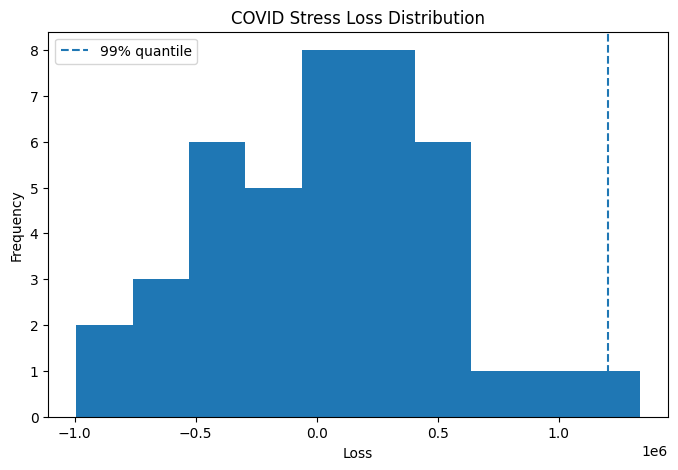

In [16]:
covid_tail = covid_losses.quantile(0.99)
plt.figure(figsize=(8,5))
plt.hist(covid_losses, bins=10)
plt.axvline(covid_tail, linestyle="--",label="99% quantile")
plt.title("COVID Stress Loss Distribution")
plt.xlabel("Loss")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [ ]:
# Exception Statistics
exceptions = covid_var["Exception"].sum()
n_obs = len(covid_var)

print("Crisis VaR Performance")
print("----------------------")
print(f"Observations: {n_obs}")
print(f"Exceptions: {exceptions}")
print(f"Exception rate: {exceptions/n_obs:.3f}")

Crisis VaR Performance
----------------------
Observations: 41
Exceptions: 5
Exception rate: 0.122


Severity Metrics
----------------
Worst loss: 1335696.88
Average VaR: 861530.96
Worst loss / VaR: 1.55


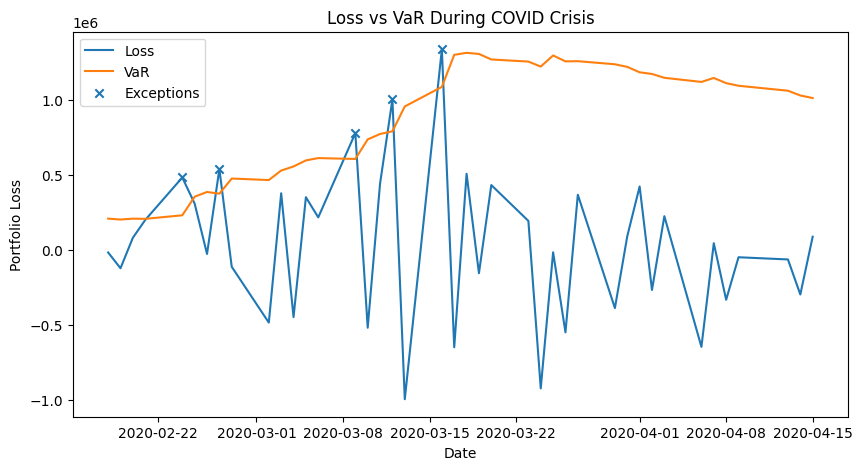

In [21]:
# Worsrt losses vs VaR
worst_loss = covid_var["Loss"].max()
avg_var = covid_var["VaR"].mean()

print("Severity Metrics")
print("----------------")
print(f"Worst loss: {worst_loss:.2f}")
print(f"Average VaR: {avg_var:.2f}")
print(f"Worst loss / VaR: {worst_loss/avg_var:.2f}")

# Plot
plt.figure(figsize=(10,5))

plt.plot(covid_var.index, covid_var["Loss"], label="Loss")
plt.plot(covid_var.index, covid_var["VaR"], label="VaR")

plt.scatter(
    exceptions.index,
    exceptions["Loss"],
    marker="x",
    label="Exceptions"
)

plt.legend()
plt.title("Loss vs VaR During COVID Crisis")
plt.xlabel("Date")
plt.ylabel("Portfolio Loss")

plt.show()

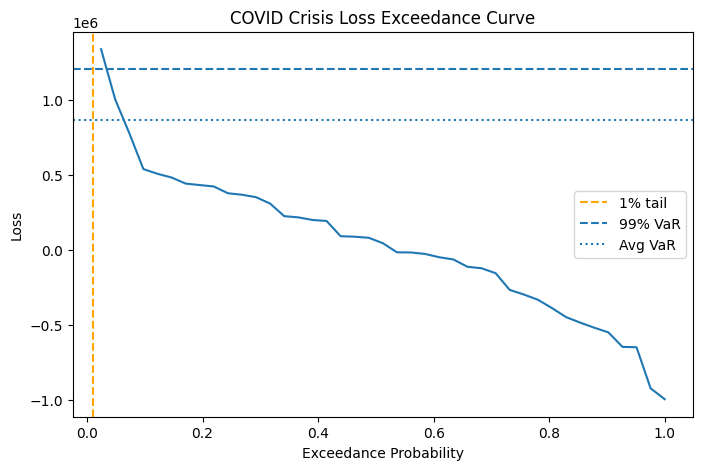

In [24]:
# Loss exceedance curve (tail plot)

sorted_losses = covid_losses.sort_values(ascending=False).reset_index(drop=True)

exceedance_prob = (sorted_losses.index + 1) / len(sorted_losses)

plt.figure(figsize=(8,5))

plt.plot(exceedance_prob, sorted_losses)

plt.axvline(0.01, linestyle="--", label="1% tail", color="orange")
plt.axhline(covid_tail, linestyle="--", label="99% VaR")
plt.axhline(covid_var["VaR"].mean(), linestyle=":", label="Avg VaR")

plt.xlabel("Exceedance Probability")
plt.ylabel("Loss")
plt.title("COVID Crisis Loss Exceedance Curve")

plt.legend()

plt.show()

The loss exceedance curve shows a steep increase in losses among the worst observations, indicating that extreme losses escalate rapidly beyond the 99% VaR threshold. However, the small sample size of the COVID stress window limits the precision of tail probability estimates.

### Historical Crisis Summary

The COVID crash produced losses substantially larger than the model's
normal risk estimates.

The parametric EWMA VaR model experienced 5 exceptions over the crisis
period's 41 observations, translating to an exception rate of 0.122 which is significantly above the expected rate for a 99% VaR model.

The largest observed loss was 1.55 times larger than the average VaR
forecast, showing that the model moderately underestimates tail severity in extreme market
conditions.